<a href="https://www.kaggle.com/code/sonawanelalitsunil/restaurant-orders-dataset-ml-29-33?scriptVersionId=258810644" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/restaurant-orders/restaurant_orders.csv


## 📌 Restaurant Orders Dataset

## Detailed Description:
The Restaurant Orders dataset contains information about customer food orders placed at a restaurant. It can include details such as order ID, customer information, food items ordered, quantity, price, payment method, and order time. This dataset is useful for analyzing sales trends, customer preferences, menu performance, peak dining hours, and revenue patterns. It can also be applied to build predictive models for demand forecasting, recommendation systems for food items, and strategies to improve restaurant operations and customer satisfaction.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/restaurant-orders/restaurant_orders.csv")

In [3]:
df.head()

,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time
0,2268,Mary Vega DDS,Pasta,Main,5,16.52,Cash,2025-02-02 14:28:41
1,3082,Brandon Myers,Brownie,Dessert,4,17.27,Debit Card,2025-06-08 10:57:47
2,3160,Margaret Wells,Pasta,Main,1,3.37,Credit Card,2025-03-04 07:41:41
3,1272,Michael Matthews,Pasta,Main,5,2.20,Online Payment,2025-05-15 12:43:45
4,9447,Connor Williams,Soup,Starter,1,12.23,Cash,2025-03-15 14:25:56


In [4]:
df.tail()

,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time
495,6323,Alyssa Anthony,Pizza,Main,1,21.31,Cash,2025-01-15 19:21:02
496,9836,Jerry Pineda,Soup,Starter,3,15.99,Debit Card,2025-07-15 15:00:19
497,1202,Brandy Smith,Pasta,Main,2,8.54,Credit Card,2025-08-03 23:47:28
498,7876,Ivan Haynes,Soup,Starter,5,20.54,Credit Card,2025-07-23 08:10:06
499,1509,Amber Mendez,Ice Cream,Dessert,2,18.86,Online Payment,2025-08-09 05:11:27


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        500 non-null    int64  
 1   Customer Name   500 non-null    object 
 2   Food Item       500 non-null    object 
 3   Category        500 non-null    object 
 4   Quantity        500 non-null    int64  
 5   Price           500 non-null    float64
 6   Payment Method  500 non-null    object 
 7   Order Time      500 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 31.4+ KB


In [6]:
df.describe()

,Order ID,Quantity,Price
count,500.000000,500.000000,500.000000
mean,5683.296000,3.030000,13.197180
std,2599.688068,1.474261,6.685852
min,1055.000000,1.000000,2.060000
25%,3342.000000,2.000000,7.280000
50%,5762.000000,3.000000,13.305000
75%,7945.000000,4.000000,19.080000
max,9997.000000,5.000000,24.990000


In [7]:
df.isnull().sum()

Order ID          0
Customer Name     0
Food Item         0
Category          0
Quantity          0
Price             0
Payment Method    0
Order Time        0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Order ID            int64
Customer Name      object
Food Item          object
Category           object
Quantity            int64
Price             float64
Payment Method     object
Order Time         object
dtype: object

In [10]:
df.shape

(500, 8)

In [11]:
df.columns

Index(['Order ID', 'Customer Name', 'Food Item', 'Category', 'Quantity',
       'Price', 'Payment Method', 'Order Time'],
      dtype='object')

## Data visualizations

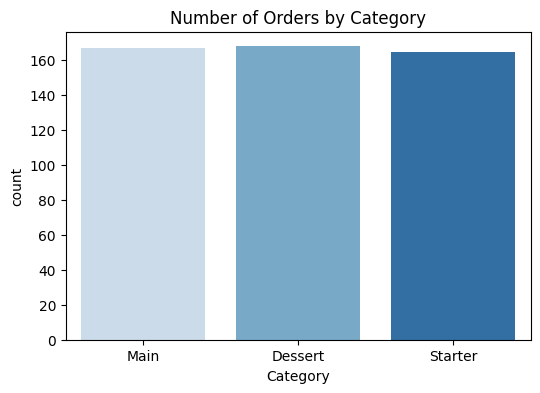

In [12]:
# 1. Orders by Category
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Category', palette='Blues')
plt.title("Number of Orders by Category")
plt.show()

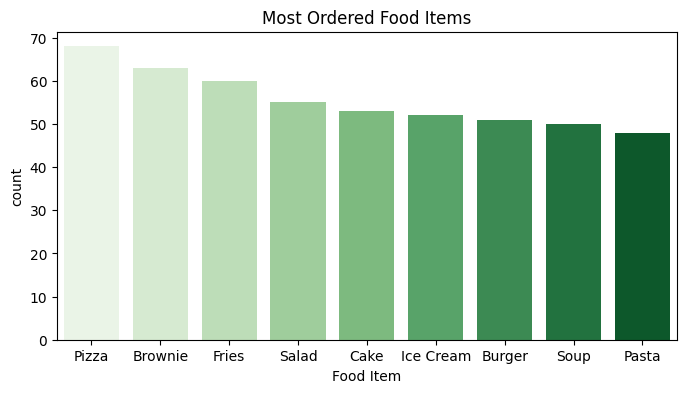

In [13]:
# 2. Most Ordered Food Items
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Food Item', order=df['Food Item'].value_counts().index, palette='Greens')
plt.title("Most Ordered Food Items")
plt.show()

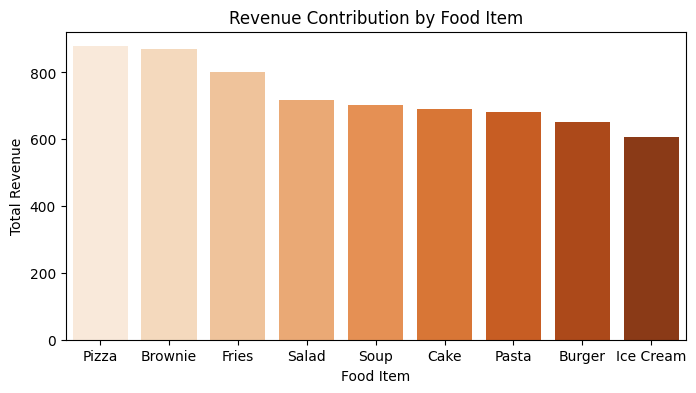

In [14]:
# 3. Revenue Contribution by Food Item
revenue_per_item = df.groupby("Food Item")['Price'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=revenue_per_item.index, y=revenue_per_item.values, palette='Oranges')
plt.title("Revenue Contribution by Food Item")
plt.ylabel("Total Revenue")
plt.show()


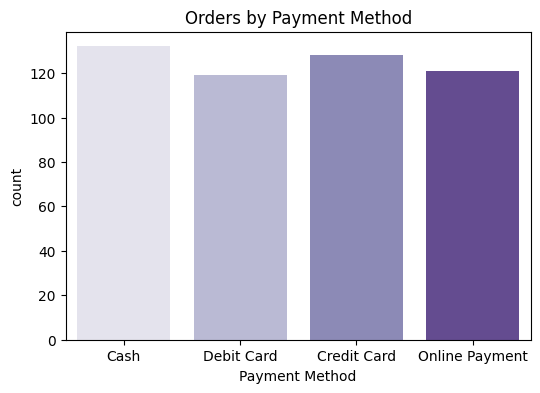

In [15]:
# 4. Orders by Payment Method
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Payment Method', palette='Purples')
plt.title("Orders by Payment Method")
plt.show()


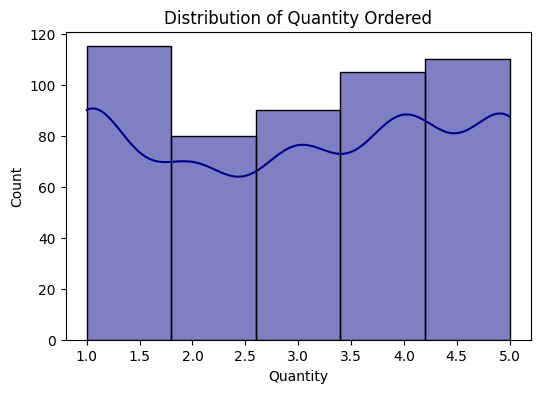

In [16]:
# 5. Distribution of Quantity Ordered
plt.figure(figsize=(6,4))
sns.histplot(df['Quantity'], bins=5, kde=True, color='darkblue')
plt.title("Distribution of Quantity Ordered")
plt.show()

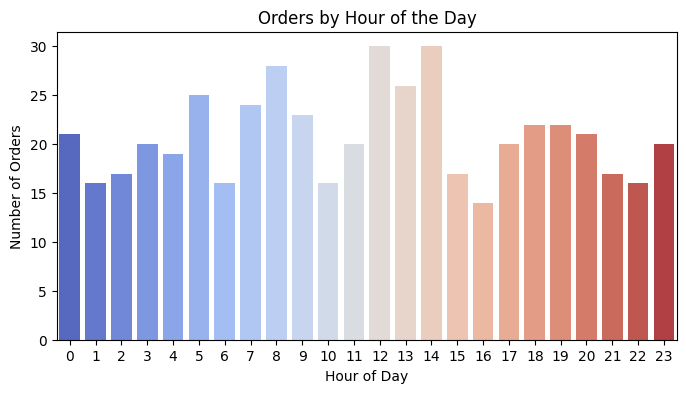

In [17]:
df['Order Time'] = pd.to_datetime(df['Order Time'], errors='coerce')

# Extract only the hour
df['Hour'] = df['Order Time'].dt.hour

# Plot orders by hour
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Hour', palette='coolwarm')
plt.title("Orders by Hour of the Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()

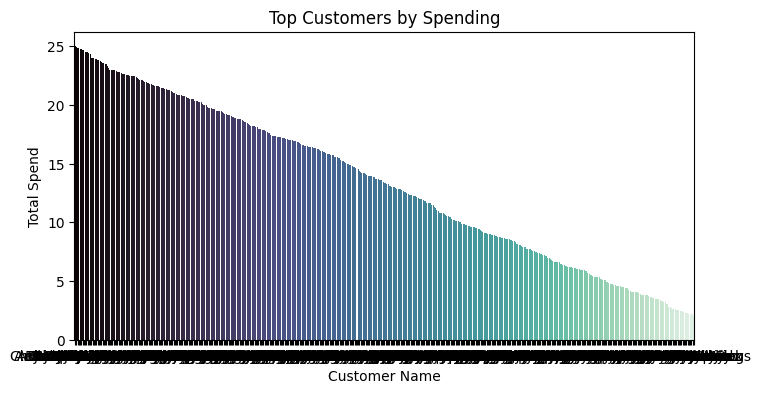

In [18]:
# 7. Top Customers by Spending
customer_spending = df.groupby("Customer Name")['Price'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=customer_spending.index, y=customer_spending.values, palette='mako')
plt.title("Top Customers by Spending")
plt.ylabel("Total Spend")
plt.show()

## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [20]:
# Convert datetime
df['Order Time'] = pd.to_datetime(df['Order Time'], errors='coerce')
df['Hour'] = df['Order Time'].dt.hour

# Drop unnecessary columns
df = df.drop(['Order ID','Order Time','Customer Name'], axis=1)

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop('Payment Method', axis=1)
y = df['Payment Method']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Train & Evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    results[name] = round(acc, 2)

# ------------------ SHOW RESULTS ------------------
for name, acc in results.items():
    print(f"{name}: {acc}% Accuracy")


Logistic Regression: 20.67% Accuracy
Decision Tree: 22.67% Accuracy
Random Forest: 28.67% Accuracy
Gradient Boosting: 24.0% Accuracy
KNN: 29.33% Accuracy
SVM: 27.33% Accuracy
Naive Bayes: 20.0% Accuracy
XGBoost: 26.0% Accuracy


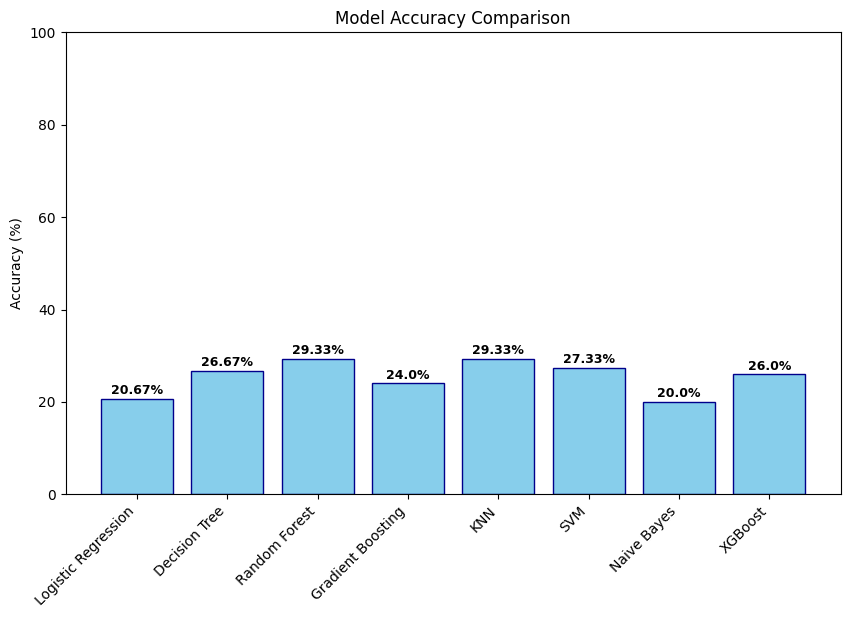

In [22]:
import matplotlib.pyplot as plt

# Results dictionary (replace with your results if needed)
results = {
    "Logistic Regression": 20.67,
    "Decision Tree": 26.67,
    "Random Forest": 29.33,
    "Gradient Boosting": 24.0,
    "KNN": 29.33,
    "SVM": 27.33,
    "Naive Bayes": 20.0,
    "XGBoost": 26.0
}

# Plot bar chart
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values(), color='skyblue', edgecolor='darkblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

# Add accuracy values on top of bars
for i, (model, acc) in enumerate(results.items()):
    plt.text(i, acc + 1, f"{acc}%", ha='center', fontsize=9, fontweight='bold')

plt.show()

## Thank you...pls upvote!!!